In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

Due to the severity of this real-world crisis, what information would be the most important to "machine learn"? Can it be learned?

The information that is most important is factors that could lead to a high suicide rate or low suicide rate. We have to figure out if certain demographic information can help us figure this out. This information can be learned as the feature that will help us include age group, gender, gdp per capita, and more. It is important to note that we are simply trying to find a correlation, as these factors may not cause suicide rates.

Explain in detail how one should set up the problem. Would it be a regression or a classification problem? Is any unsupervised approach, to look for patterns, worthwhile?

This would be a classification problem since at the end we are trying to figure out between two binary classes, low suicide rate, or high suicide rate. Regression could have been used to find the suicides/100k pop for example, however I am going to set up the problem in a classification mindset. I will set up a new variable which will be 0 or 1 represent low or high suicide rate respectively. This varible will be based on the suicides/100k pop and we will use the median to differentiate the two classes. An unsupervised approach may not be helpful, as we have labels for our data and we aren't looking data without any target.

What should be the dependent variable?
The dependent variable should be our newly created 'high_suicide_rate' column which as mention above, will be based on the suicides/100k pop, by making the numerical column into a discrete column

Find some strong correlations between the independent variables and the dependent variable you decided and use them to rank the independent variables

In [2]:
df = pd.read_csv('suicideRates.csv')

In [3]:
df

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27820 entries, 0 to 27819
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   country             27820 non-null  object 
 1   year                27820 non-null  int64  
 2   sex                 27820 non-null  object 
 3   age                 27820 non-null  object 
 4   suicides_no         27820 non-null  int64  
 5   population          27820 non-null  int64  
 6   suicides/100k pop   27820 non-null  float64
 7   country-year        27820 non-null  object 
 8   HDI for year        8364 non-null   float64
 9    gdp_for_year ($)   27820 non-null  object 
 10  gdp_per_capita ($)  27820 non-null  int64  
 11  generation          27820 non-null  object 
dtypes: float64(2), int64(4), object(6)
memory usage: 2.5+ MB


In [5]:
df.columns

Index(['country', 'year', 'sex', 'age', 'suicides_no', 'population',
       'suicides/100k pop', 'country-year', 'HDI for year',
       ' gdp_for_year ($) ', 'gdp_per_capita ($)', 'generation'],
      dtype='object')

In [6]:
df.isnull().any()

country               False
year                  False
sex                   False
age                   False
suicides_no           False
population            False
suicides/100k pop     False
country-year          False
HDI for year           True
 gdp_for_year ($)     False
gdp_per_capita ($)    False
generation            False
dtype: bool

In [7]:
df.isnull().sum()

country                   0
year                      0
sex                       0
age                       0
suicides_no               0
population                0
suicides/100k pop         0
country-year              0
HDI for year          19456
 gdp_for_year ($)         0
gdp_per_capita ($)        0
generation                0
dtype: int64

In [8]:
df[-20:]

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation
27800,Uzbekistan,2013,male,55-74 years,119,1202790,9.89,Uzbekistan2013,0.672,"57,690,453,461",2150,Boomers
27801,Uzbekistan,2013,male,75+ years,13,221002,5.88,Uzbekistan2013,0.672,"57,690,453,461",2150,Silent
27802,Uzbekistan,2013,female,25-34 years,146,2647820,5.51,Uzbekistan2013,0.672,"57,690,453,461",2150,Millenials
27803,Uzbekistan,2013,female,35-54 years,99,3547895,2.79,Uzbekistan2013,0.672,"57,690,453,461",2150,Generation X
27804,Uzbekistan,2013,female,75+ years,8,345180,2.32,Uzbekistan2013,0.672,"57,690,453,461",2150,Silent
27805,Uzbekistan,2013,male,5-14 years,61,2720938,2.24,Uzbekistan2013,0.672,"57,690,453,461",2150,Generation Z
27806,Uzbekistan,2013,female,55-74 years,21,1356298,1.55,Uzbekistan2013,0.672,"57,690,453,461",2150,Boomers
27807,Uzbekistan,2013,female,5-14 years,31,2595000,1.19,Uzbekistan2013,0.672,"57,690,453,461",2150,Generation Z
27808,Uzbekistan,2014,male,35-54 years,519,3421300,15.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X
27809,Uzbekistan,2014,male,25-34 years,318,2739150,11.61,Uzbekistan2014,0.675,"63,067,077,179",2309,Millenials


In [9]:
data = df['suicides/100k pop'].groupby(df.country).sum()

In [10]:
data

country
Albania                  924.76
Antigua and Barbuda      179.14
Argentina               3894.59
Armenia                  976.21
Aruba                   1596.52
                         ...   
United Arab Emirates      94.89
United Kingdom          2790.92
United States           5140.97
Uruguay                 6538.96
Uzbekistan              2138.17
Name: suicides/100k pop, Length: 101, dtype: float64

<Axes: xlabel='country'>

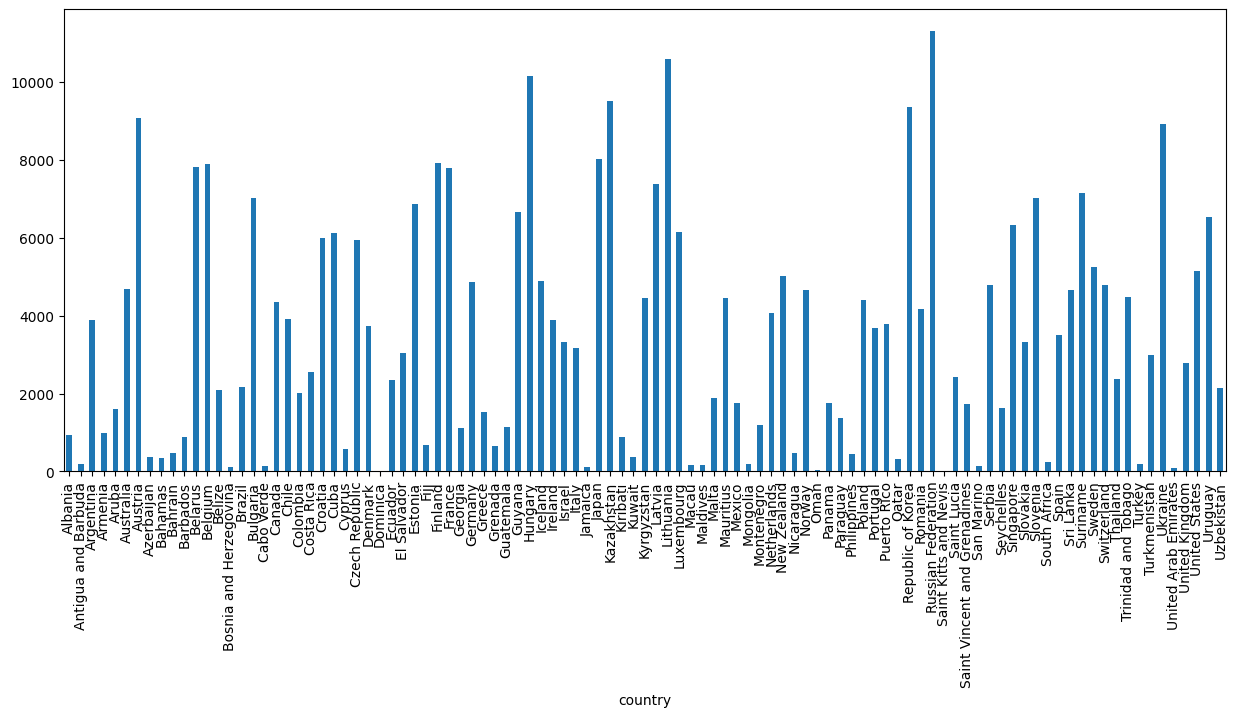

In [11]:
plt.figure(figsize=(15, 6))
data.plot(kind='bar')

In [12]:
median_suicides = df['suicides/100k pop'].median()

# Create a binary column
df['high_suicide_rate'] = (df['suicides/100k pop'] > median_suicides).astype(int)

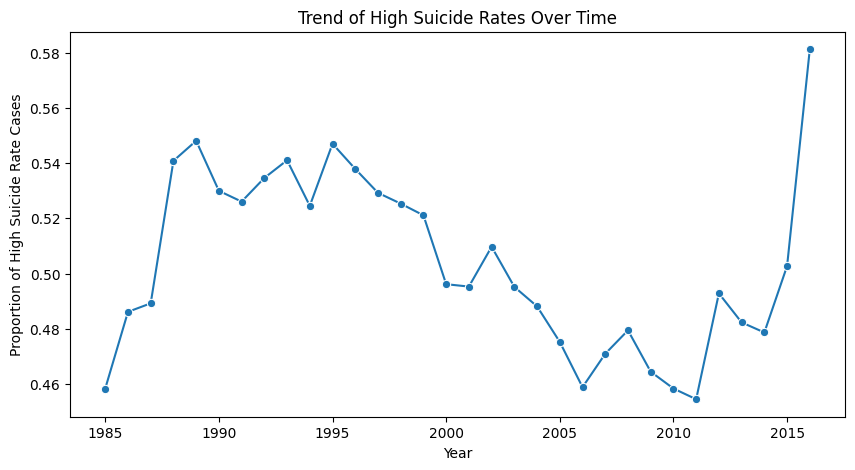

In [13]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=df.groupby("year")["high_suicide_rate"].mean().reset_index(), x="year", y="high_suicide_rate", marker="o")
plt.title("Trend of High Suicide Rates Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of High Suicide Rate Cases")
plt.show()

/var/folders/zr/t__wp83506l98w_p0vv3wrrm0000gn/T/ipykernel_31617/2673551501.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="sex", y="high_suicide_rate", ci=None)


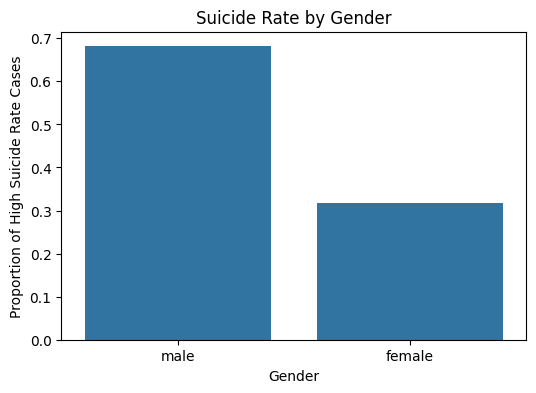

In [14]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x="sex", y="high_suicide_rate", ci=None)
plt.title("Suicide Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Proportion of High Suicide Rate Cases")
plt.show()

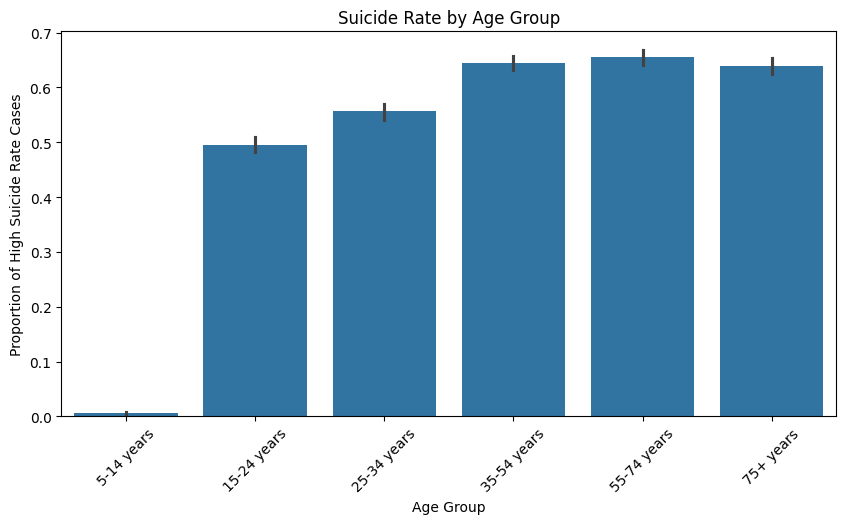

In [15]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="age", y="high_suicide_rate", order=["5-14 years", "15-24 years", "25-34 years", "35-54 years", "55-74 years", "75+ years"])
plt.title("Suicide Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Proportion of High Suicide Rate Cases")
plt.xticks(rotation=45)
plt.show()

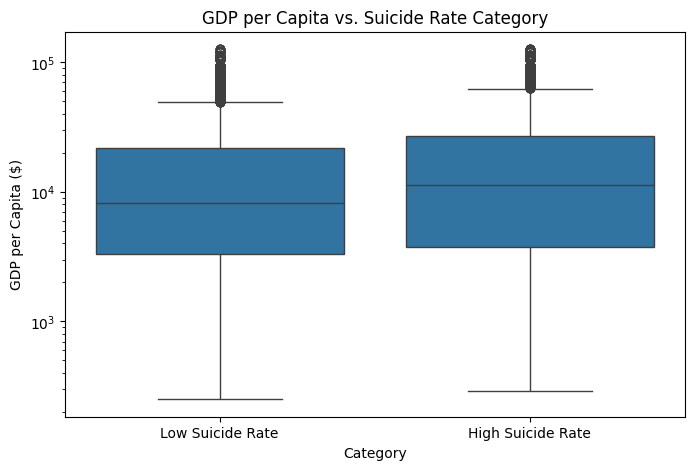

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="high_suicide_rate", y="gdp_per_capita ($)")
plt.xticks([0, 1], ["Low Suicide Rate", "High Suicide Rate"])
plt.title("GDP per Capita vs. Suicide Rate Category")
plt.xlabel("Category")
plt.ylabel("GDP per Capita ($)")
plt.yscale("log")
plt.show()

In [17]:
df

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation,high_suicide_rate
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X,1
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent,0
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X,0
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation,0
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X,0
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent,0
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z,0
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z,0


In [18]:
for col in df.columns:
    if df[col].dtype == object:
        print (col, df[col].unique())

country ['Albania' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba' 'Australia'
 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Barbados' 'Belarus' 'Belgium'
 'Belize' 'Bosnia and Herzegovina' 'Brazil' 'Bulgaria' 'Cabo Verde'
 'Canada' 'Chile' 'Colombia' 'Costa Rica' 'Croatia' 'Cuba' 'Cyprus'
 'Czech Republic' 'Denmark' 'Dominica' 'Ecuador' 'El Salvador' 'Estonia'
 'Fiji' 'Finland' 'France' 'Georgia' 'Germany' 'Greece' 'Grenada'
 'Guatemala' 'Guyana' 'Hungary' 'Iceland' 'Ireland' 'Israel' 'Italy'
 'Jamaica' 'Japan' 'Kazakhstan' 'Kiribati' 'Kuwait' 'Kyrgyzstan' 'Latvia'
 'Lithuania' 'Luxembourg' 'Macau' 'Maldives' 'Malta' 'Mauritius' 'Mexico'
 'Mongolia' 'Montenegro' 'Netherlands' 'New Zealand' 'Nicaragua' 'Norway'
 'Oman' 'Panama' 'Paraguay' 'Philippines' 'Poland' 'Portugal'
 'Puerto Rico' 'Qatar' 'Republic of Korea' 'Romania' 'Russian Federation'
 'Saint Kitts and Nevis' 'Saint Lucia' 'Saint Vincent and Grenadines'
 'San Marino' 'Serbia' 'Seychelles' 'Singapore' 'Slovakia' 'Slovenia'


In [19]:
df['gdp_per_capita ($)'].dtype

dtype('int64')

Pre-process the dataset and list the major features you want to use.
age,sex,gdp_per_capita,year,country

In [20]:
def encode_onehot(_df, _f):
    _df2 = pd.get_dummies(_df[_f], prefix=_f, prefix_sep=' - ', dtype=int)
    _df3 = pd.concat([_df, _df2], axis=1)
    _df3 = _df3.drop([_f], axis=1)
    return _df3

In [21]:
df_o = df.copy()


In [22]:
df_o

,country,year,sex,age,suicides_no,population,suicides/100k pop,country-year,HDI for year,gdp_for_year ($),gdp_per_capita ($),generation,high_suicide_rate
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,"2,156,624,900",796,Generation X,1
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,"2,156,624,900",796,Silent,0
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,"2,156,624,900",796,Generation X,0
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,"2,156,624,900",796,G.I. Generation,0
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,"2,156,624,900",796,Boomers,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,female,35-54 years,107,3620833,2.96,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation X,0
27816,Uzbekistan,2014,female,75+ years,9,348465,2.58,Uzbekistan2014,0.675,"63,067,077,179",2309,Silent,0
27817,Uzbekistan,2014,male,5-14 years,60,2762158,2.17,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z,0
27818,Uzbekistan,2014,female,5-14 years,44,2631600,1.67,Uzbekistan2014,0.675,"63,067,077,179",2309,Generation Z,0


In [23]:
df_o = df.copy()
df_o = df_o.drop(['suicides_no', 'generation', 'country-year',' gdp_for_year ($) ', 'HDI for year', 'population', 'suicides/100k pop'], axis=1)
df_o = encode_onehot(df_o, 'sex')
df_o = encode_onehot(df_o, 'age')

In [24]:
df_o

,country,year,gdp_per_capita ($),high_suicide_rate,sex - female,sex - male,age - 15-24 years,age - 25-34 years,age - 35-54 years,age - 5-14 years,age - 55-74 years,age - 75+ years
0,Albania,1987,796,1,0,1,1,0,0,0,0,0
1,Albania,1987,796,0,0,1,0,0,1,0,0,0
2,Albania,1987,796,0,1,0,1,0,0,0,0,0
3,Albania,1987,796,0,0,1,0,0,0,0,0,1
4,Albania,1987,796,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,Uzbekistan,2014,2309,0,1,0,0,0,1,0,0,0
27816,Uzbekistan,2014,2309,0,1,0,0,0,0,0,0,1
27817,Uzbekistan,2014,2309,0,0,1,0,0,0,1,0,0
27818,Uzbekistan,2014,2309,0,1,0,0,0,0,1,0,0


In [25]:
df_o['country_encoded'] = pd.factorize(df['country'])[0]

In [26]:
df_o = df_o.drop('country', axis=1)

In [27]:
df_o

,year,gdp_per_capita ($),high_suicide_rate,sex - female,sex - male,age - 15-24 years,age - 25-34 years,age - 35-54 years,age - 5-14 years,age - 55-74 years,age - 75+ years,country_encoded
0,1987,796,1,0,1,1,0,0,0,0,0,0
1,1987,796,0,0,1,0,0,1,0,0,0,0
2,1987,796,0,1,0,1,0,0,0,0,0,0
3,1987,796,0,0,1,0,0,0,0,0,1,0
4,1987,796,0,0,1,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27815,2014,2309,0,1,0,0,0,1,0,0,0,100
27816,2014,2309,0,1,0,0,0,0,0,0,1,100
27817,2014,2309,0,0,1,0,0,0,1,0,0,100
27818,2014,2309,0,1,0,0,0,0,1,0,0,100


Devise a classification problem and present a working prototype model.

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score  # f1_score can be used too
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split

# Converting from class labels integers
# df_o['recurrence'] = df_o['recurrence'].replace({'recurrence-events':1, 'no-recurrence-events':0})

# We will reuse the classifier function below
def rf_train_test(_X_tr, _X_ts, _y_tr, _y_ts):
    rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=0, n_jobs=4)
    rf.fit(_X_tr, _y_tr)
    y_pred = rf.predict(_X_ts)

    return accuracy_score(_y_ts, y_pred)

In [29]:
X = df_o.loc[:, df_o.columns != 'high_suicide_rate'].values

In [30]:
y = df_o.loc[:, df_o.columns == 'high_suicide_rate'].values.ravel()

In [31]:
df_o['high_suicide_rate'].value_counts()

high_suicide_rate
0    13914
1    13906
Name: count, dtype: int64

In [32]:
for i in range(10):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=i)
    print(rf_train_test(X_train, X_test, y_train, y_test))

0.783608914450036
0.7893601725377426
0.7852264557872034
0.7916966211358735
0.7897196261682243
0.7927749820273184
0.7852264557872034
0.790079079798706
0.7958303378864127
0.7848670021567218


In [33]:
Accuracies = []
kfold = KFold(n_splits=10,shuffle=False)
for train_index, test_index in kfold.split(X, y):
    acc = rf_train_test(X[train_index], X[test_index], y[train_index], y[test_index])
    Accuracies += [acc]

print(f'10-fold cross-validation accuracy is {np.mean(Accuracies):.3f} {chr(177)}{np.std(Accuracies):.4f}')

10-fold cross-validation accuracy is 0.765 ±0.0483
